# 6.2.2 复指数与离散频谱

## 学习目标与先修知识

能用复数（complex number）表示旋转，解释 离散傅里叶变换（discrete Fourier transform，DFT）的投影（projection）含义；从有限实数序列计算单边幅度谱（one-sided amplitude spectrum）与相位谱（phase spectrum），正确处理零频率、记录长度奇偶和零幅度。

先修：[采样与混叠](../01-观测、采样与滤波/01-采样间隔与混叠.ipynb)、[加权求和与卷积](01-从脉冲响应到线性卷积.ipynb)、向量（vector）内积（inner product）、三角函数。复数和变换的定义在本节引入，不要求预先学过傅里叶分析。

In [ ]:
from systems_science.local_service import notebook_service_ready
notebook_service_ready()

## 具体问题

浓度（concentration）偏差可以同时包含慢节律、快节律和非零平均值。直接看时间曲线难以分别量出它们的振幅（amplitude）与时间位置。我们将有限序列分解成一组规定频率的旋转，再说明“谱上的高度”到底采用哪一种单位和归一化。

In [1]:
import math
import numpy as np
import matplotlib.pyplot as plt
from IPython.display import Markdown, display
from systems_science import plot_style, show_table
plot_style()
BLUE, PINK, GRAY = '#008bfb', '#ff0051', '#555555'

## 初步实验

In [2]:
theta=np.pi/3
z=complex(np.cos(theta),np.sin(theta))
display(Markdown(show_table(['量','数值'],[['实部',z.real],['虚部',z.imag],['模长',abs(z)],['角度 / rad',np.angle(z)]])))
print('相乘后的实部与 cos(2θ)：',float((z*z).real),float(np.cos(2*theta)))

| 量 | 数值 |
| --- | --- |
| 实部 | 0.5 |
| 虚部 | 0.866025 |
| 模长 | 1 |
| 角度 / rad | 1.0472 |

相乘后的实部与 cos(2θ)： -0.4999999999999998 -0.4999999999999998


## 模型假设

给定 $N\ge1$ 个有限实数观测（observation） $x_n$，$n=0,\ldots,N-1$，单位 U，规则采样率（sampling rate）为 $f_s>0$ Hz。时间原点固定为第 0 个样本；平移原点会改变相位（phase）。这里没有窗加权，也没有缺失点。输出（output）描述**这段记录**，不是直接给出生理系统在所有时刻的真实频率分布（distribution）。

## 数学解释与推导

### 从二维坐标到旋转

令 $i^2=-1$，$z=a+ib$ 把两个实数保存为平面坐标，模长（modulus）为 $|z|=\sqrt{a^2+b^2}$，相角为 $\operatorname{atan2}(b,a)$，单位 rad。复共轭（complex conjugate）$\bar z=a-ib$ 把旋转方向反过来。Python 用 `1j` 表示 $i$。

欧拉公式（Euler's formula）$e^{i\theta}=\cos\theta+i\sin\theta$ 把单位圆上的点写成指数。一个解释是两侧在 $\theta=0$ 都等于 1，且导数（derivative）都为自身乘 $i$，因此遵循相同的旋转微分方程。相乘让角度相加：$e^{i\alpha}e^{i\beta}=e^{i(\alpha+\beta)}$；而

$$\cos\theta=\frac{e^{i\theta}+e^{-i\theta}}2.$$

### 为什么要乘“反向旋转”再求和

定义 $X_k=\sum_{n=0}^{N-1}x_n e^{-i2\pi kn/N}$，$k=0,\ldots,N-1$。若 $x_n$ 以相同频率正向旋转，两次旋转相消，各项同向相加；不同整数频率绕满圆后抵消。由等比求和，令 $r=e^{i2\pi(k-\ell)/N}$，则 $r\ne1$ 时 $\sum_{n=0}^{N-1}r^n=(1-r^N)/(1-r)=0$，相同频率时和为 $N$。这给出逆式

$$x_n=\frac1N\sum_{k=0}^{N-1}X_k e^{i2\pi kn/N}.$$

这里正变换不除以 $N$，逆变换除以 $N$；快速傅里叶变换（fast Fourier transform，FFT）只是更快计算同一离散变换的算法，不改变公式。频率间隔为 $\Delta f=f_s/N$，第 $k$ 格频率 $f_k=kf_s/N$。

### 实数记录的单边规则

实数输入（input）满足 $X_{N-k}=\bar X_k$。因此只保留 $k=0,\ldots,\lfloor N/2\rfloor$，振幅定义为

$$a_k=\begin{cases}|X_k|/N,&k=0\text{，或 }N\text{ 为偶数且 }k=N/2,\\2|X_k|/N,&\text{其余保留项。}\end{cases}$$

这是把一对正负旋转合成余弦后的幅值，单位仍为 U。对于恰好落在内部整数格上的 $A\cos(2\pi kn/N+\phi)$，且 $A\ge0$，它返回幅值 $A$ 和相位 $\phi$（模 $2\pi$）。DC（direct current，直流）指零频率：有符号均值为 $X_0/N$，幅度取绝对值；负均值由相位 $\pi$ 搭配表达。偶数 $N$ 的奈奎斯特项没有另一独立伙伴，不乘 2；奇数 $N$ 的最后一格仍在 $f_s/2$ 下方，要乘 2。奈奎斯特采样（sampling）下正弦分量不可见，不能由该格恢复任意连续余弦的相位与振幅。

相位取 $\arg X_k\in(-\pi,\pi]$；数值上距 $-\pi$ 不超过 $10^{-12}$ rad 的结果统一记为 $+\pi$，使边界只有一种表示。零幅的角度没有物理意义。为避免浮点抵消误差生成随机角度，本节明确规定：当 $|X_k|/N\le10^{-12}\max(1,\max_n|x_n|)$ 时返回幅值 0、相位 0。0 是表示约定，**不是测得相位为 0**；阈值基于本节 U 数值标度，不是通用弱信号检测准则。非整数频率的幅值解释还受有限记录影响，下一节展开。

## 核心实现

先显式实现双重求和；输出三条同长度列表，依次为 Hz、U、rad。所有规则都保留在代码中。

In [3]:
def one_sided_spectrum(values, sample_rate):
    x=np.asarray(values,dtype=float)
    if x.ndim!=1 or x.size==0 or not np.all(np.isfinite(x)) or not math.isfinite(sample_rate) or sample_rate<=0:
        raise ValueError('需要非空一维有限实数序列与正采样率')
    count=len(x)
    # 显式 DFT：先算归一化双边系数，未调用 FFT。
    coefficients=[]
    for k in range(count//2+1):
        total=0j
        for n,value in enumerate(x):
            angle=-2*math.pi*k*n/count
            total+=value*complex(math.cos(angle),math.sin(angle))
        coefficients.append(total/count)
    threshold=1e-12*max(1.,float(np.max(np.abs(x))))
    frequencies=[];amplitudes=[];phases=[]
    for k,z in enumerate(coefficients):
        edge=(k==0 or (count%2==0 and k==count//2))
        amplitude=abs(z)*(1 if edge else 2)
        phase=math.atan2(z.imag,z.real)
        if abs(phase+math.pi)<=1e-12:
            phase=math.pi
        if abs(z)<=threshold:
            amplitude=0.;phase=0.
        frequencies.append(k*sample_rate/count)
        amplitudes.append(float(amplitude));phases.append(float(phase))
    return frequencies,amplitudes,phases

## 对照实验

记录含平均值 0.4 U、1 Hz 的 1.2 U 分量和 2.5 Hz 的 0.5 U 分量；本例恰好落在频率格上。相位只画有效幅度的位置。

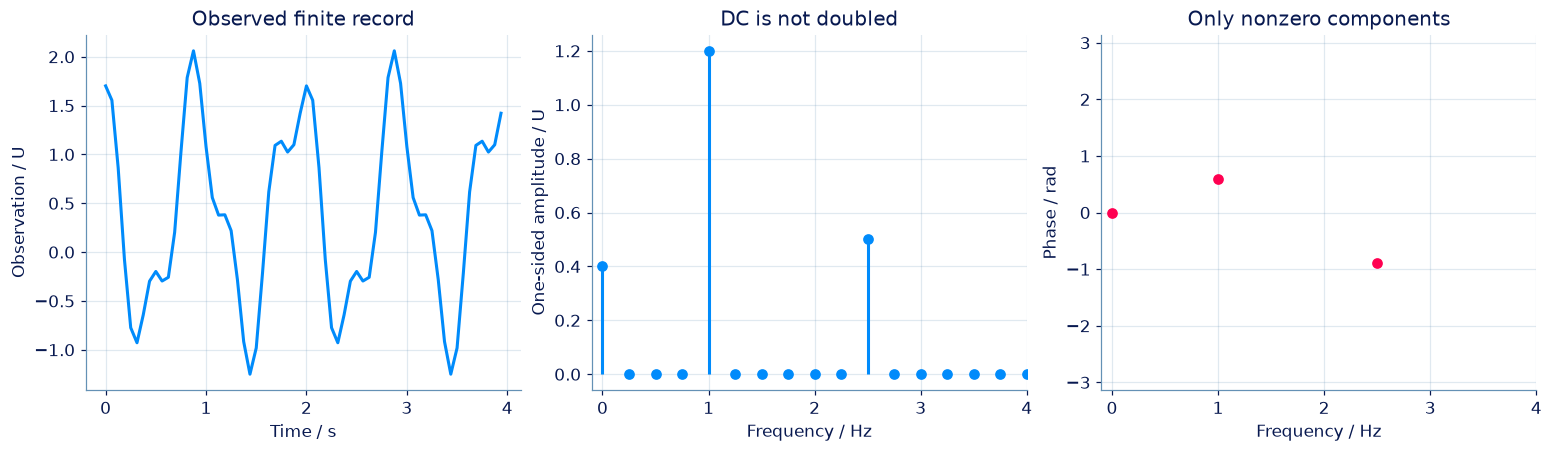

| 频率 / Hz | 幅值 / U | 相位 / rad |
| --- | --- | --- |
| 0 | 0.4 | 0 |
| 1 | 1.2 | 0.6 |
| 2.5 | 0.5 | -0.9 |

In [4]:
fs=16.;N=64;t=np.arange(N)/fs
x=.4+1.2*np.cos(2*np.pi*1*t+.6)+.5*np.cos(2*np.pi*2.5*t-.9)
freq,amplitude,phase=map(np.array,one_sided_spectrum(x,fs))
active=amplitude>0
fig,axes=plt.subplots(1,3,figsize=(14,4))
axes[0].plot(t,x,color=BLUE);axes[0].set(xlabel='Time / s',ylabel='Observation / U',title='Observed finite record')
axes[1].stem(freq,amplitude,linefmt=BLUE,markerfmt='o',basefmt=' ')
axes[1].set(xlabel='Frequency / Hz',ylabel='One-sided amplitude / U',title='DC is not doubled',xlim=(-.1,4))
axes[2].scatter(freq[active],phase[active],color=PINK)
axes[2].set(xlabel='Frequency / Hz',ylabel='Phase / rad',title='Only nonzero components',xlim=(-.1,4),ylim=(-np.pi,np.pi))
plt.show()
display(Markdown(show_table(['频率 / Hz','幅值 / U','相位 / rad'],zip(freq[active],amplitude[active],phase[active]))))

## 结果解释

三条频率成分与设计条件一致；这依赖整数频率格和已说明的归一化。幅度平方的单位是 U²，不应把这里的幅度谱直接标为功率谱密度。相位参照当前记录的时间起点；缺失格上的 0 不能作为相位观测使用。

### 独立核对

分别构造 DC、偶长度奈奎斯特、奇长度最高格及全零边界。用 FFT 检查独立实现的求和，再按单边余弦重建本例。

In [5]:
_,a,p=one_sided_spectrum([-2.]*8,8)
np.testing.assert_allclose(a,[2,0,0,0,0]);np.testing.assert_allclose(abs(p[0]),np.pi)
_,a,_=one_sided_spectrum([1,-1]*4,8);np.testing.assert_allclose(a,[0,0,0,0,1])
_,a,_=one_sided_spectrum(np.cos(2*np.pi*2*np.arange(5)/5),5)
np.testing.assert_allclose(a,[0,0,1],atol=1e-13)
assert one_sided_spectrum([0.,0.,0.],3)==([0.,1.],[0.,0.],[0.,0.])
assert one_sided_spectrum([3.],7)==([0.],[3.],[0.])
fft_coeff=np.fft.rfft(x)/N
np.testing.assert_allclose(amplitude[1:-1],2*np.abs(fft_coeff[1:-1]),atol=2e-14)
reconstructed=sum(a*np.cos(2*np.pi*f*t+p) for f,a,p in zip(freq,amplitude,phase))
np.testing.assert_allclose(reconstructed,x,atol=1e-13)
print('DC、奇偶长度、奈奎斯特、零幅、FFT 对照和重建检查通过。')

DC、奇偶长度、奈奎斯特、零幅、FFT 对照和重建检查通过。


[观察本章的动态可视化](http://127.0.0.1:8000/chapters/06-02-卷积、频谱与频率响应/explore/)：改变采样或窗口条件，比较图形后返回本节推导。

## 练习与参考资料

习题由统一题库同步。

## 练习与参考资料

先独立作答，再提交核对。

### 第 1 题 · Python 计算题：给有限记录标上正确频率

给定实值等间隔记录，显式计算离散傅里叶变换（discrete Fourier transform，DFT）的单边频率、幅值和相位（phase），不使用连续曲线的已知参数（parameter）代替计算。

**函数与代码模板**

```python
def solve(
    values: list[float],
    sample_rate: float,
) -> tuple[list[float], list[float], list[float]]:
    # 按题目定义返回计算结果。
    raise NotImplementedError("请完成计算")
```

**参数说明**

| 名称 | Python 类型 | 含义 | 单位 |
|---|---|---|---|
| `values` | `list[float]` | 等间隔实值样本，首个样本时刻定义为0。 | U |
| `sample_rate` | `float` | 每秒观察次数。 | Hz |

**返回值**

按以下顺序返回元组：(frequencies, amplitudes, phases)。

| 名称 | Python 类型 | 含义 | 单位 |
|---|---|---|---|
| `frequencies` | `list[float]` | k*fs/N，k=0…floor(N/2)。 | Hz |
| `amplitudes` | `list[float]` | 下述规则定义的单边幅值。 | U |
| `phases` | `list[float]` | 对应DFT系数相位，零幅处按约定返回0。 | rad |

**计算规则**

X[k]=Σ_n values[n]*exp(−2πikn/N)。双边幅值 r=abs(X[k])/N；r≤1e−12*max(1,max(abs(values))) 时该幅值和相位都返回0。其他点：DC及偶数N的Nyquist不加倍，其余幅值乘2。相位取 atan2(Im,Re) 的主值，距离−π≤1e−12时统一为+π，即使用(−π,π]端点约定。

**约束与边界**

- 所有非缺测数值有限；不修改输入（input）列表。
- 1≤N≤32；0<sample_rate≤100，sample_rate≥0.01；每项绝对值≤100。

**输入样例**

每个参数对应函数签名中的同名变量；单位与顺序见下表。

给定条件

| 参数 | 含义 | 给定值 | 单位 |
| --- | --- | --- | --- |
| values | 等间隔实值样本，首个样本时刻定义为0。 | [1.0, 0.0, -1.0, 0.0] | U |
| sample_rate | 每秒观察次数。 | 4 | Hz |

**输入与调用代码**

完成 solve 函数后，将下面的参数赋值与调用代码放在函数定义下方运行。

```python
values = [1.0, 0.0, -1.0, 0.0]
sample_rate = 4.0

result = solve(values, sample_rate)
print(result)
```

**输出样例**

对这组输入，你的函数应返回下列结果。列表按表格自上而下的顺序排列；标有“≈”的是便于阅读的近似值，请按模型计算完整数值。

计算结果

| 返回项 | 含义 | 结果 | 单位 |
| --- | --- | --- | --- |
| frequencies | k*fs/N，k=0…floor(N/2)。 | [0.0, 1.0, 2.0] | Hz |
| amplitudes | 下述规则定义的单边幅值。 | [0.0, 1.0, 0.0] | U |
| phases | 对应DFT系数相位，零幅处按约定返回0。 | [0.0, 6.123233995736766e-17, 0.0] | rad |

**预期输出代码**

用 expected_output 对照 result 的类型、顺序与数值。代码保留样例原始精度，浮点结果按题面容差比较。

```python
expected_output = ([0.0, 1.0, 2.0],
                   [0.0, 1.0, 0.0],
                   [0.0, 6.123233995736766e-17, 0.0])
```

**样例解释**

输入是一个周期的1 Hz余弦，返回频率 [0,1,2] Hz，幅值 [0,1,0] U，相位 [0,0,0] rad。无幅值的频点相位0仅是题定标记。

允许 Python 标准库；绝对误差 1e-09 或相对误差 1e-08。

[作答：给有限记录标上正确频率](http://127.0.0.1:8000/chapters/06-02-%E5%8D%B7%E7%A7%AF%E3%80%81%E9%A2%91%E8%B0%B1%E4%B8%8E%E9%A2%91%E7%8E%87%E5%93%8D%E5%BA%94/practice/?question=p06-one-sided-spectrum)

### 第 2 题 · 多项选择题：复指数怎样表示相位

采用 exp(iθ)=cosθ+i sinθ。哪些正确？

- **A.** 复数（complex number）模长（modulus）与相角分别可表示幅度和相位（phase）。
- **B.** DFT的正负频率对实信号没有任何关系。
- **C.** cosθ=(exp(iθ)+exp(−iθ))/2。
- **D.** 乘 exp(iφ) 会把复平面向量（vector）旋转 φ。

[作答：复指数怎样表示相位](http://127.0.0.1:8000/chapters/06-02-%E5%8D%B7%E7%A7%AF%E3%80%81%E9%A2%91%E8%B0%B1%E4%B8%8E%E9%A2%91%E7%8E%87%E5%93%8D%E5%BA%94/practice/?question=p06-complex-rotation)

### 第 3 题 · 单项选择题：Nyquist点为什么不乘二

记录 [1,−1,1,−1] U，fs=4 Hz，N=4。单边幅度谱（one-sided amplitude spectrum）中哪项正确？

- **A.** 频率坐标最后一项为4 Hz。
- **B.** 该记录只有DC成分。
- **C.** 2 Hz处幅值为1 U，不再乘二。
- **D.** 2 Hz处幅值为2 U，因为所有正频率均加倍。

[作答：Nyquist点为什么不乘二](http://127.0.0.1:8000/chapters/06-02-%E5%8D%B7%E7%A7%AF%E3%80%81%E9%A2%91%E8%B0%B1%E4%B8%8E%E9%A2%91%E7%8E%87%E5%93%8D%E5%BA%94/practice/?question=p06-nyquist-amplitude)

### 第 4 题 · 多项选择题：零幅频点的相位表示什么

某DFT系数理论上为0，数值误差（numerical error）给出极小非零复数（complex number）。哪些解释适当？

- **A.** 题面返回0相位（phase）不意味着存在零相位振荡。
- **B.** 零向量（vector）没有确定相角。
- **C.** 可以用阈值标记未定义相位，但必须声明约定。
- **D.** 数值atan2输出（output）可以稳定地揭示该分量的真实相位。

[作答：零幅频点的相位表示什么](http://127.0.0.1:8000/chapters/06-02-%E5%8D%B7%E7%A7%AF%E3%80%81%E9%A2%91%E8%B0%B1%E4%B8%8E%E9%A2%91%E7%8E%87%E5%93%8D%E5%BA%94/practice/?question=p06-phase-zero)

### 第 5 题 · 单项选择题：频点间隔由什么决定

N=100 个样本，fs=20 Hz，记录的DFT频点间隔是多少？

- **A.** 0.2 Hz。
- **B.** 5 Hz。
- **C.** 20 Hz。
- **D.** 0.2 rad/s。

[作答：频点间隔由什么决定](http://127.0.0.1:8000/chapters/06-02-%E5%8D%B7%E7%A7%AF%E3%80%81%E9%A2%91%E8%B0%B1%E4%B8%8E%E9%A2%91%E7%8E%87%E5%93%8D%E5%BA%94/practice/?question=p06-frequency-units)

**进一步阅读**

[NumPy 离散傅里叶变换文档](https://numpy.org/doc/stable/reference/routines.fft.html)：Implementation details、Normalization 与 Real and Hermitian transforms 的符号和归一化约定。